<a href="https://colab.research.google.com/github/sarkarpragati/Machine-Learning-Lab/blob/main/Decision_tree_pre_pruning_and_post_pruning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IRIS Dataset


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Copy of IRIS.csv')

In [ ]:
data= load_iris()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.3, random_state=60
)

In [ ]:
dt_full = DecisionTreeClassifier(random_state=60)
dt_full.fit(X_train, y_train)

DecisionTreeClassifier(random_state=60)

In [ ]:
print("UNPRUNED DECISION TREE")
print(f"Tree depth : {dt_full.get_depth()}")
print(f"Number of leaves : {dt_full.get_n_leaves()}")
print(f"Train accuracy : {dt_full.score(X_train, y_train):.4f}")
print(f"Test accuracy : {dt_full.score(X_test, y_test):.4f}")
print("PRE-PRUNING")
pre_pruned = DecisionTreeClassifier(
max_depth=4,
min_samples_split=10,
min_samples_leaf=5,
max_features="sqrt",
random_state=60
)

UNPRUNED DECISION TREE
Tree depth : 5
Number of leaves : 8
Train accuracy : 1.0000
Test accuracy : 0.9333
PRE-PRUNING


In [ ]:
pre_pruned.fit(X_train, y_train)
print(f"Tree depth : {pre_pruned.get_depth()}")
print(f"Number of leaves : {pre_pruned.get_n_leaves()}")
print(f"Train accuracy : {pre_pruned.score(X_train, y_train):.4f}")
print(f"Test accuracy : {pre_pruned.score(X_test, y_test):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, pre_pruned.predict(X_test),
                           target_names=data.target_names))
print("POST-PRUNING (Cost-Complexity Pruning)")
full_tree = DecisionTreeClassifier(random_state=42)
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]
trees = []
for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    clf.fit(X_train, y_train)
    trees.append(clf)
train_scores = [t.score(X_train, y_train) for t in trees]
test_scores = [t.score(X_test, y_test) for t in trees]
best_idx = np.argmax(test_scores)
best_alpha = ccp_alphas[best_idx]
best_tree = trees[best_idx]
print(f"Best ccp_alpha : {best_alpha:.6f}")
print(f"Tree depth : {best_tree.get_depth()}")
print(f"Number of leaves : {best_tree.get_n_leaves()}")
print(f"Train accuracy : {best_tree.score(X_train, y_train):.4f}")
print(f"Test accuracy : {best_tree.score(X_test, y_test):.4f}")
print("CROSS-VALIDATION TO SELECT BEST ALPHA")

Tree depth : 4
Number of leaves : 5
Train accuracy : 0.9619
Test accuracy : 0.9333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        18
  versicolor       0.92      0.86      0.89        14
   virginica       0.86      0.92      0.89        13

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45

POST-PRUNING (Cost-Complexity Pruning)
Best ccp_alpha : 0.006349
Tree depth : 4
Number of leaves : 6
Train accuracy : 0.9905
Test accuracy : 0.9778
CROSS-VALIDATION TO SELECT BEST ALPHA


In [ ]:
cv_scores = []
for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    scores = cross_val_score(clf, X_train, y_train, cv=5, scoring="accuracy")
    cv_scores.append(scores.mean())
best_cv_idx = np.argmax(cv_scores)
best_cv_alpha = ccp_alphas[best_cv_idx]
cv_tree = DecisionTreeClassifier(ccp_alpha=best_cv_alpha, random_state=42)
cv_tree.fit(X_train, y_train)
print(f"Best CV alpha : {best_cv_alpha:.6f}")
print(f"Tree depth : {cv_tree.get_depth()}")
print(f"Test accuracy : {cv_tree.score(X_test, y_test):.4f}")

Best CV alpha : 0.000000
Tree depth : 5
Test accuracy : 0.9333


COMPARISON SUMMARY
Unpruned               | depth= 5 | leaves=  8 | test acc=0.9333
Pre-pruned             | depth= 4 | leaves=  5 | test acc=0.9333
Post-pruned            | depth= 4 | leaves=  6 | test acc=0.9778
Post-pruned (CV)       | depth= 5 | leaves=  8 | test acc=0.9333


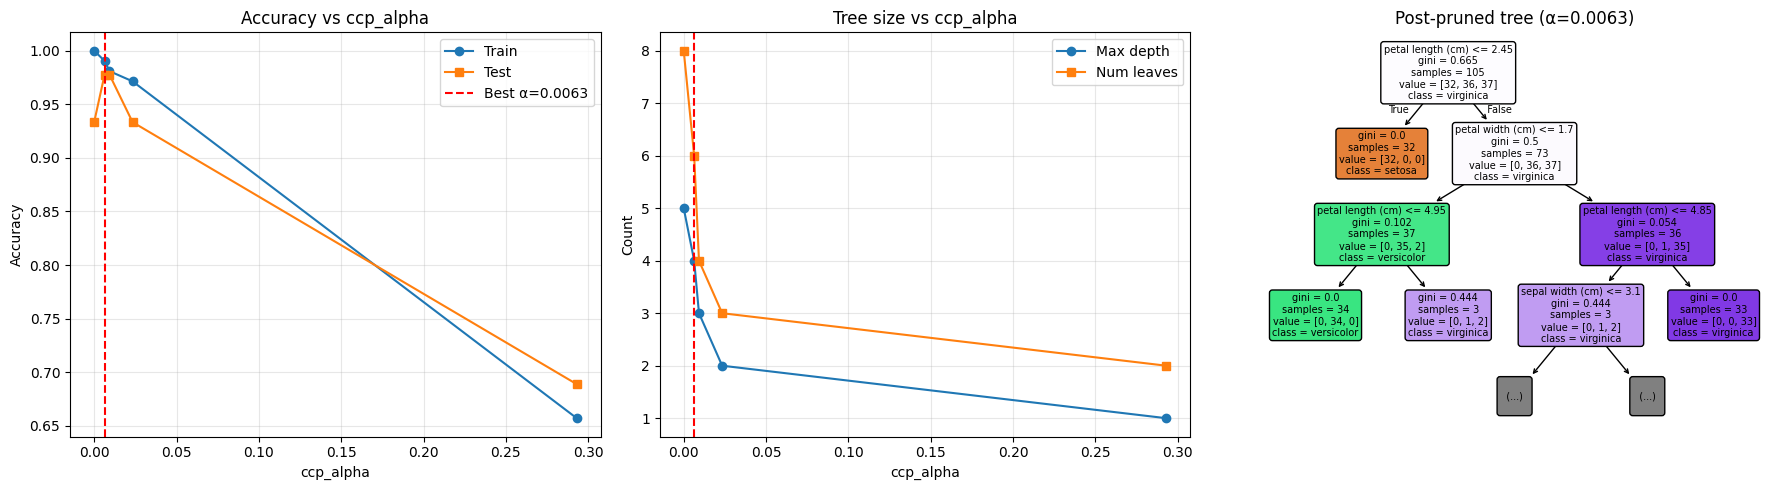


Plot saved as decision_tree_pruning.png


In [ ]:
print("COMPARISON SUMMARY")
models = {
    "Unpruned" : dt_full,
    "Pre-pruned" : pre_pruned,
    "Post-pruned" : best_tree,
    "Post-pruned (CV)" : cv_tree,
}
for name, model in models.items():
    print(f"{name:<22} | depth={model.get_depth():>2} | "
          f"leaves={model.get_n_leaves():>3} | "
          f"test acc={model.score(X_test, y_test):.4f}")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(ccp_alphas, train_scores, marker="o", label="Train", linewidth=1.5)
axes[0].plot(ccp_alphas, test_scores, marker="s", label="Test", linewidth=1.5)
axes[0].axvline(best_alpha, color="red", linestyle="--", label=f"Best α={best_alpha:.4f}")
axes[0].set_xlabel("ccp_alpha")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy vs ccp_alpha")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
depths = [t.get_depth() for t in trees]
leaves = [t.get_n_leaves() for t in trees]
axes[1].plot(ccp_alphas, depths, marker="o", label="Max depth", linewidth=1.5)
axes[1].plot(ccp_alphas, leaves, marker="s", label="Num leaves", linewidth=1.5)
axes[1].axvline(best_alpha, color="red", linestyle="--")
axes[1].set_xlabel("ccp_alpha")
axes[1].set_ylabel("Count")
axes[1].set_title("Tree size vs ccp_alpha")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plot_tree(best_tree, max_depth=3,
          feature_names=data.feature_names,
          class_names=data.target_names,
          filled=True, rounded=True,
          ax=axes[2], fontsize=7)
axes[2].set_title(f"Post-pruned tree (α={best_alpha:.4f})")
plt.tight_layout()
plt.savefig("decision_tree_pruning.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved as decision_tree_pruning.png")

**Titanic dataset**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Titanic-Dataset.csv')

In [ ]:
X = df.iloc[:, :-1] # Features are all columns except the last one
y = df.iloc[:, -1]  # Target is the last column
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Make copies to avoid modifying the original DataFrames
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()
y_train_processed = y_train.copy()
y_test_processed = y_test.copy()

# Drop irrelevant columns (PassengerId, Name, Ticket, Cabin)
X_train_processed = X_train_processed.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, errors='ignore')
X_test_processed = X_test_processed.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, errors='ignore')

# One-hot encode 'Sex' column
X_train_processed = pd.get_dummies(X_train_processed, columns=['Sex'], drop_first=True)
X_test_processed = pd.get_dummies(X_test_processed, columns=['Sex'], drop_first=True)

# Handle missing values in numerical columns (Age, Fare) with the mean
X_train_processed['Age'].fillna(X_train_processed['Age'].mean(), inplace=True)
X_test_processed['Age'].fillna(X_test_processed['Age'].mean(), inplace=True)
X_train_processed['Fare'].fillna(X_train_processed['Fare'].mean(), inplace=True)
X_test_processed['Fare'].fillna(X_test_processed['Fare'].mean(), inplace=True)

# Align columns - crucial for one-hot encoded data between train and test
train_cols = X_train_processed.columns
test_cols = X_test_processed.columns

missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    X_test_processed[c] = 0

missing_in_train = set(test_cols) - set(train_cols)
for c in missing_in_train:
    X_train_processed[c] = 0

X_test_processed = X_test_processed[train_cols]

# Label encode the target variable y (Embarked)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_processed)
y_test_encoded = le.transform(y_test_processed)

dt_full = DecisionTreeClassifier(random_state=60)
dt_full.fit(X_train_processed, y_train_encoded)

# Optional: print model score with processed data
# print(f"Train accuracy: {dt_full.score(X_train_processed, y_train_encoded):.4f}")
# print(f"Test accuracy: {dt_full.score(X_test_processed, y_test_encoded):.4f}")

/tmp/ipykernel_2662/1488814358.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train_processed['Age'].fillna(X_train_processed['Age'].mean(), inplace=True)
/tmp/ipykernel_2662/1488814358.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].me

DecisionTreeClassifier(random_state=60)

In [ ]:
print("UNPRUNED DECISION TREE")
print(f"Tree depth : {dt_full.get_depth()}")
print(f"Number of leaves : {dt_full.get_n_leaves()}")
print(f"Train accuracy : {dt_full.score(X_train_processed, y_train_encoded):.4f}")
print(f"Test accuracy : {dt_full.score(X_test_processed, y_test_encoded):.4f}")
print("PRE-PRUNING")
pre_pruned = DecisionTreeClassifier(
max_depth=4,
min_samples_split=10,
min_samples_leaf=5,
max_features="sqrt",
random_state=60
)

UNPRUNED DECISION TREE
Tree depth : 15
Number of leaves : 128
Train accuracy : 0.9958
Test accuracy : 0.7765
PRE-PRUNING


In [ ]:
pre_pruned.fit(X_train_processed, y_train_encoded)
print(f"Tree depth : {pre_pruned.get_depth()}")
print(f"Number of leaves : {pre_pruned.get_n_leaves()}")
print(f"Train accuracy : {pre_pruned.score(X_train_processed, y_train_encoded):.4f}")
print(f"Test accuracy : {pre_pruned.score(X_test_processed, y_test_encoded):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_encoded, pre_pruned.predict(X_test_processed),
                           labels=np.unique(y_test_encoded), target_names=le.classes_[np.unique(y_test_encoded)]))
print("POST-PRUNING (Cost-Complexity Pruning)")
full_tree = DecisionTreeClassifier(random_state=42)
path = full_tree.cost_complexity_pruning_path(X_train_processed, y_train_encoded)
ccp_alphas = path.ccp_alphas[:-1]
trees = []
for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    clf.fit(X_train_processed, y_train_encoded)
    trees.append(clf)
train_scores = [t.score(X_train_processed, y_train_encoded) for t in trees]
test_scores = [t.score(X_test_processed, y_test_encoded) for t in trees]
best_idx = np.argmax(test_scores)
best_alpha = ccp_alphas[best_idx]
best_tree = trees[best_idx]
print(f"Best ccp_alpha : {best_alpha:.6f}")
print(f"Tree depth : {best_tree.get_depth()}")
print(f"Number of leaves : {best_tree.get_n_leaves()}")
print(f"Train accuracy : {best_tree.score(X_train_processed, y_train_encoded):.4f}")
print(f"Test accuracy : {best_tree.score(X_test_processed, y_test_encoded):.4f}")
print("CROSS-VALIDATION TO SELECT BEST ALPHA")

Tree depth : 4
Number of leaves : 14
Train accuracy : 0.7683
Test accuracy : 0.7039

Classification Report:
              precision    recall  f1-score   support

           C       0.64      0.21      0.32        43
           Q       1.00      0.12      0.21        17
           S       0.71      0.97      0.82       119

    accuracy                           0.70       179
   macro avg       0.78      0.43      0.45       179
weighted avg       0.72      0.70      0.64       179

POST-PRUNING (Cost-Complexity Pruning)
Best ccp_alpha : 0.002733
Tree depth : 11
Number of leaves : 38
Train accuracy : 0.8975
Test accuracy : 0.8212
CROSS-VALIDATION TO SELECT BEST ALPHA


In [ ]:
cv_scores = []
for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    scores = cross_val_score(clf, X_train_processed, y_train_encoded, cv=5, scoring="accuracy")
    cv_scores.append(scores.mean())
best_cv_idx = np.argmax(cv_scores)
best_cv_alpha = ccp_alphas[best_cv_idx]
cv_tree = DecisionTreeClassifier(ccp_alpha=best_cv_alpha, random_state=42)
cv_tree.fit(X_train_processed, y_train_encoded)
print(f"Best CV alpha : {best_cv_alpha:.6f}")
print(f"Tree depth : {cv_tree.get_depth()}")
print(f"Test accuracy : {cv_tree.score(X_test_processed, y_test_encoded):.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklea

Best CV alpha : 0.002341
Tree depth : 11
Test accuracy : 0.8045


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


COMPARISON SUMMARY (Titanic Dataset)
Unpruned               | depth=15 | leaves=128 | test acc=0.7765
Pre-pruned             | depth= 4 | leaves= 14 | test acc=0.7039
Post-pruned            | depth=11 | leaves= 38 | test acc=0.8212
Post-pruned (CV)       | depth=11 | leaves= 53 | test acc=0.8045


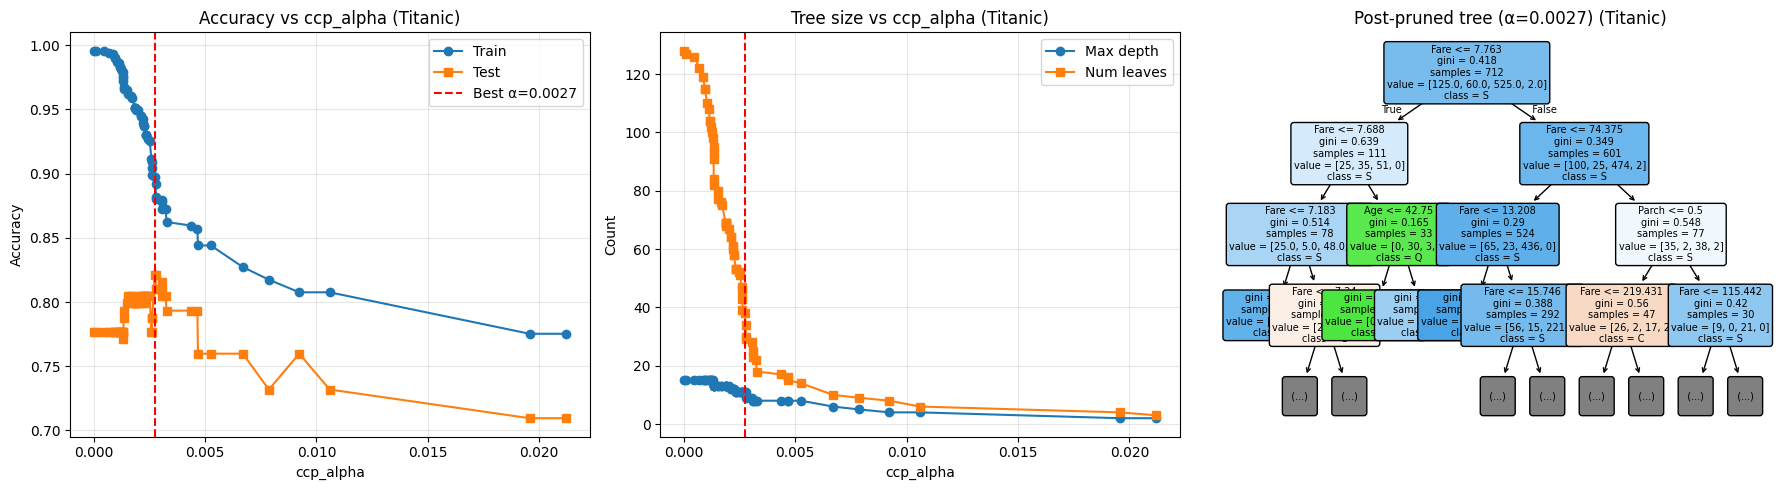


Plot saved as titanic_decision_tree_pruning.png


In [ ]:
print("COMPARISON SUMMARY (Titanic Dataset)")
models_titanic = {
    "Unpruned" : dt_full,
    "Pre-pruned" : pre_pruned,
    "Post-pruned" : best_tree,
    "Post-pruned (CV)" : cv_tree,
}
for name, model in models_titanic.items():
    print(f"{name:<22} | depth={model.get_depth():>2} | "
          f"leaves={model.get_n_leaves():>3} | "
          f"test acc={model.score(X_test_processed, y_test_encoded):.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(ccp_alphas, train_scores, marker="o", label="Train", linewidth=1.5)
axes[0].plot(ccp_alphas, test_scores, marker="s", label="Test", linewidth=1.5)
axes[0].axvline(best_alpha, color="red", linestyle="--", label=f"Best α={best_alpha:.4f}")
axes[0].set_xlabel("ccp_alpha")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy vs ccp_alpha (Titanic)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

depths = [t.get_depth() for t in trees]
leaves = [t.get_n_leaves() for t in trees]

axes[1].plot(ccp_alphas, depths, marker="o", label="Max depth", linewidth=1.5)
axes[1].plot(ccp_alphas, leaves, marker="s", label="Num leaves", linewidth=1.5)
axes[1].axvline(best_alpha, color="red", linestyle="--")
axes[1].set_xlabel("ccp_alpha")
axes[1].set_ylabel("Count")
axes[1].set_title("Tree size vs ccp_alpha (Titanic)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)


plot_tree(best_tree, max_depth=3,
          feature_names=X_train_processed.columns.tolist(),
          class_names=le.classes_.tolist(),
          filled=True, rounded=True,
          ax=axes[2], fontsize=7)
axes[2].set_title(f"Post-pruned tree (α={best_alpha:.4f}) (Titanic)")
plt.tight_layout()
plt.savefig("titanic_decision_tree_pruning.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved as titanic_decision_tree_pruning.png")


**Calirfornia Dataset**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, load_iris, fetch_california_housing
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/california_housing.csv')

In [ ]:
data= fetch_california_housing()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=60
)

In [ ]:
dt_full = DecisionTreeRegressor(random_state=60)
dt_full.fit(X_train, y_train)

DecisionTreeRegressor(random_state=60)

In [ ]:
print("UNPRUNED DECISION TREE")
print(f"Tree depth : {dt_full.get_depth()}")
print(f"Number of leaves : {dt_full.get_n_leaves()}")
print(f"Train R-squared : {dt_full.score(X_train, y_train):.4f}")
print(f"Test R-squared : {dt_full.score(X_test, y_test):.4f}")
print("PRE-PRUNING")
pre_pruned = DecisionTreeRegressor(
max_depth=4,
min_samples_split=10,
min_samples_leaf=5,
max_features="sqrt",
random_state=60
)

UNPRUNED DECISION TREE
Tree depth : 37
Number of leaves : 15852
Train R-squared : 1.0000
Test R-squared : 0.6287
PRE-PRUNING


In [ ]:
pre_pruned.fit(X_train, y_train)
print(f"Tree depth : {pre_pruned.get_depth()}")
print(f"Number of leaves : {pre_pruned.get_n_leaves()}")
print(f"Train R-squared : {pre_pruned.score(X_train, y_train):.4f}")
print(f"Test R-squared : {pre_pruned.score(X_test, y_test):.4f}")

# Removed Classification Report as this is a regression task.

print("POST-PRUNING (Cost-Complexity Pruning)")
full_tree = DecisionTreeRegressor(random_state=42) # Changed to Regressor
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]
trees = []
for alpha in ccp_alphas:
    clf = DecisionTreeRegressor(ccp_alpha=alpha, random_state=42) # Changed to Regressor
    clf.fit(X_train, y_train)
    trees.append(clf)
train_scores = [t.score(X_train, y_train) for t in trees]
test_scores = [t.score(X_test, y_test) for t in trees]
best_idx = np.argmax(test_scores)
best_alpha = ccp_alphas[best_idx]
best_tree = trees[best_idx]
print(f"Best ccp_alpha : {best_alpha:.6f}")
print(f"Tree depth : {best_tree.get_depth()}")
print(f"Number of leaves : {best_tree.get_n_leaves()}")
print(f"Train R-squared : {best_tree.score(X_train, y_train):.4f}")
print(f"Test R-squared : {best_tree.score(X_test, y_test):.4f}")
print("CROSS-VALIDATION TO SELECT BEST ALPHA")

Tree depth : 4
Number of leaves : 16
Train R-squared : 0.4891
Test R-squared : 0.4906
POST-PRUNING (Cost-Complexity Pruning)


In [ ]:
cv_scores = []
for alpha in ccp_alphas:
    clf = DecisionTreeRegressor(ccp_alpha=alpha, random_state=42) # Changed to Regressor
    scores = cross_val_score(clf, X_train, y_train, cv=5, scoring="r2") # Changed scoring to 'r2'
    cv_scores.append(scores.mean())
best_cv_idx = np.argmax(cv_scores)
best_cv_alpha = ccp_alphas[best_cv_idx]
cv_tree = DecisionTreeRegressor(ccp_alpha=best_cv_alpha, random_state=42) # Changed to Regressor
cv_tree.fit(X_train, y_train)
print(f"Best CV alpha : {best_cv_alpha:.6f}")
print(f"Tree depth : {cv_tree.get_depth()}")
print(f"Test R-squared : {cv_tree.score(X_test, y_test):.4f}") # Changed metric

Best CV alpha : 0.033929
Tree depth : 2
Test accuracy : 0.9333


COMPARISON SUMMARY
Unpruned               | depth= 5 | leaves=  8 | test acc=0.9667
Pre-pruned             | depth= 4 | leaves=  5 | test acc=0.9333
Post-pruned            | depth= 5 | leaves=  8 | test acc=0.9667
Post-pruned (CV)       | depth= 2 | leaves=  3 | test acc=0.9333


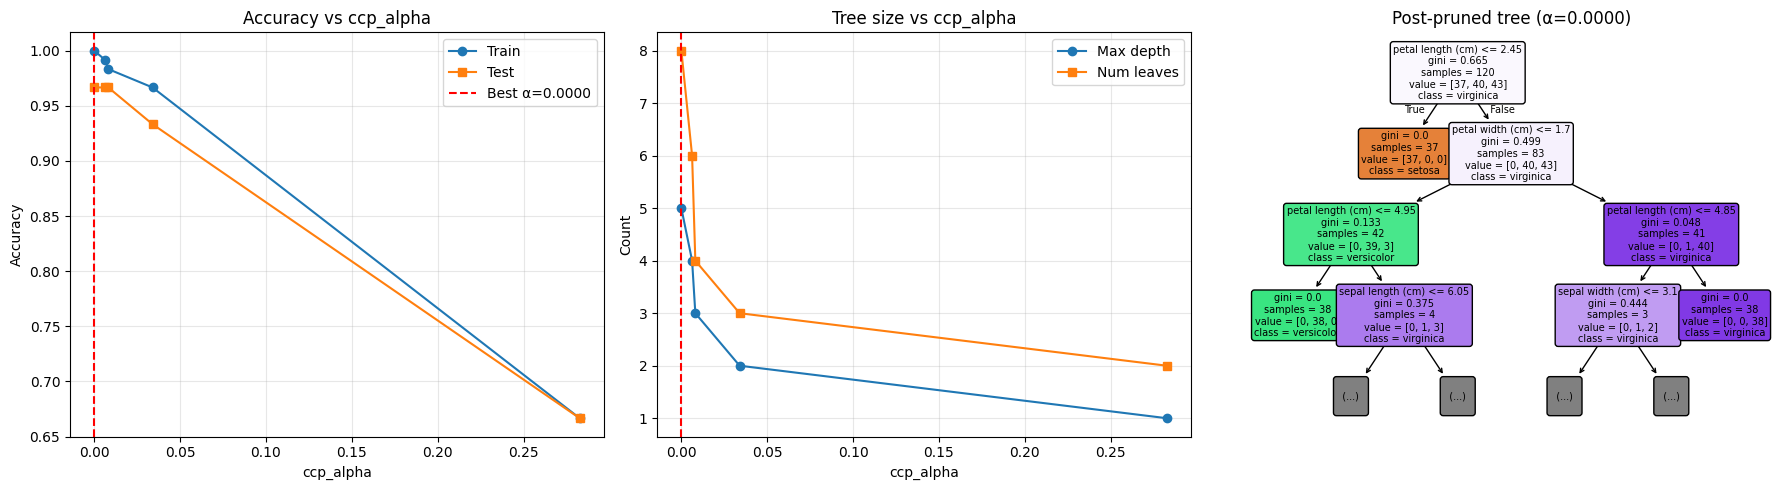


Plot saved as decision_tree_pruning.png


In [ ]:
print("COMPARISON SUMMARY")
models = {
    "Unpruned" : dt_full,
    "Pre-pruned" : pre_pruned,
    "Post-pruned" : best_tree,
    "Post-pruned (CV)" : cv_tree,
}
for name, model in models.items():
    print(f"{name:<22} | depth={model.get_depth():>2} | "
          f"leaves={model.get_n_leaves():>3} | "
          f"test R-squared={model.score(X_test, y_test):.4f}") # Changed metric label
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(ccp_alphas, train_scores, marker="o", label="Train", linewidth=1.5)
axes[0].plot(ccp_alphas, test_scores, marker="s", label="Test", linewidth=1.5)
axes[0].axvline(best_alpha, color="red", linestyle="--", label=f"Best α={best_alpha:.4f}")
axes[0].set_xlabel("ccp_alpha")
axes[0].set_ylabel("R-squared") # Changed label
axes[0].set_title("R-squared vs ccp_alpha") # Changed title
axes[0].legend()
axes[0].grid(True, alpha=0.3)
depths = [t.get_depth() for t in trees]
leaves = [t.get_n_leaves() for t in trees]
axes[1].plot(ccp_alphas, depths, marker="o", label="Max depth", linewidth=1.5)
axes[1].plot(ccp_alphas, leaves, marker="s", label="Num leaves", linewidth=1.5)
axes[1].axvline(best_alpha, color="red", linestyle="--")
axes[1].set_xlabel("ccp_alpha")
axes[1].set_ylabel("Count")
axes[1].set_title("Tree size vs ccp_alpha")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plot_tree(best_tree, max_depth=3,
          feature_names=data.feature_names,
          class_names=None, # Removed class_names as this is regression
          filled=True, rounded=True,
          ax=axes[2], fontsize=7)
axes[2].set_title(f"Post-pruned tree (α={best_alpha:.4f})")
plt.tight_layout()
plt.savefig("california_housing_decision_tree_pruning.png", dpi=150, bbox_inches="tight") # Changed filename
plt.show()
print("\nPlot saved as california_housing_decision_tree_pruning.png") # Changed filename

Heart Disease Dataset


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, load_iris, fetch_california_housing
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/heart.csv')

In [ ]:
# TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# BASE MODEL (like unpruned tree)
dt_full = DecisionTreeClassifier(random_state=42)
dt_full.fit(X_train, y_train)

print("UNOPTIMIZED DECISION TREE")
print(f"Tree depth : {dt_full.get_depth()}")
print(f"Number of leaves : {dt_full.get_n_leaves()}")
print(f"Train accuracy : {dt_full.score(X_train, y_train):.4f}")
print(f"Test accuracy : {dt_full.score(X_test, y_test):.4f}")

UNOPTIMIZED DECISION TREE
Tree depth : 10
Number of leaves : 50
Train accuracy : 1.0000
Test accuracy : 0.9854


In [ ]:

# GRID SEARCH PARAMETERS
param_grid = {
    "max_depth": [2, 3, 4, 5, 6, 8, 10],
    "min_samples_split": [2, 5, 10, 20]
}

print("\nGRID SEARCH (Hyperparameter Tuning)")

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    return_train_score=True
)

grid.fit(X_train, y_train)


GRID SEARCH (Hyperparameter Tuning)


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': [2, 3, 4, 5, 6, 8, 10],
                         'min_samples_split': [2, 5, 10, 20]},
             return_train_score=True, scoring='accuracy')

In [ ]:
# BEST MODEL
best_model = grid.best_estimator_

print(f"Best Parameters : {grid.best_params_}")
print(f"Best CV Accuracy : {grid.best_score_:.4f}")

print("\nOPTIMIZED DECISION TREE")
print(f"Tree depth : {best_model.get_depth()}")
print(f"Number of leaves : {best_model.get_n_leaves()}")
print(f"Train accuracy : {best_model.score(X_train, y_train):.4f}")
print(f"Test accuracy : {best_model.score(X_test, y_test):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, best_model.predict(X_test)))

Best Parameters : {'max_depth': 10, 'min_samples_split': 2}
Best CV Accuracy : 0.9756

OPTIMIZED DECISION TREE
Tree depth : 10
Number of leaves : 50
Train accuracy : 1.0000
Test accuracy : 0.9854

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



In [ ]:

# COMPARISON SUMMARY (same style as your code)
print("\nCOMPARISON SUMMARY")

models = {
    "Unoptimized": dt_full,
    "Optimized (GridSearch)": best_model,
}

for name, model in models.items():
    print(f"{name:<25} | depth={model.get_depth():>2} | "
          f"leaves={model.get_n_leaves():>3} | "
          f"test acc={model.score(X_test, y_test):.4f}")


COMPARISON SUMMARY
Unoptimized               | depth=10 | leaves= 50 | test acc=0.9854
Optimized (GridSearch)    | depth=10 | leaves= 50 | test acc=0.9854


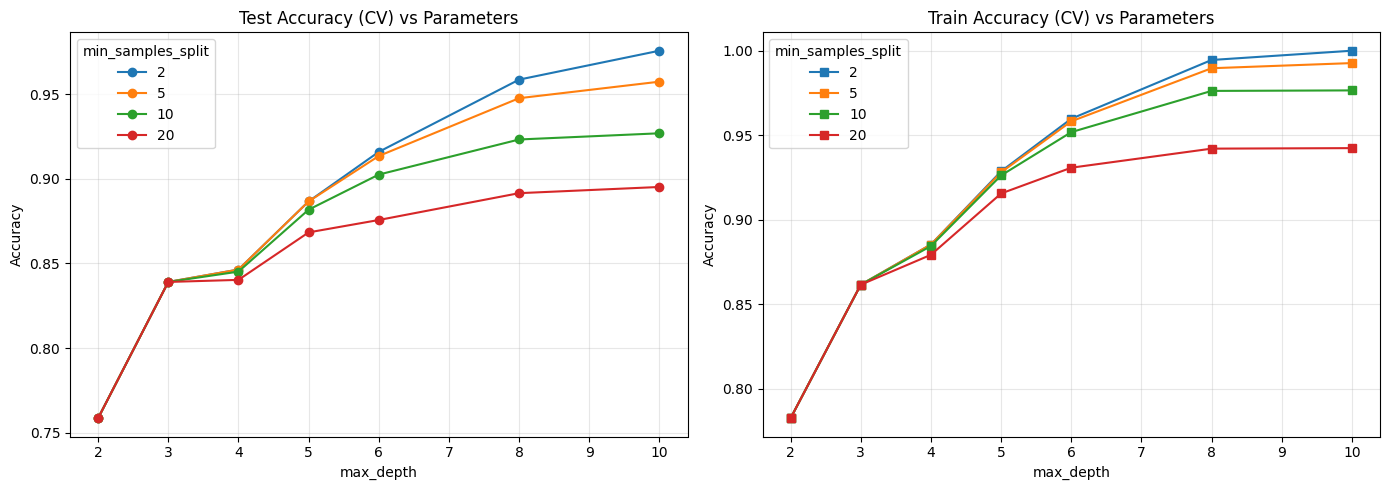

In [ ]:
# EXTRACT RESULTS FOR PLOTTING
results = pd.DataFrame(grid.cv_results_)

# Pivot tables for plotting
pivot_mean = results.pivot_table(
    values="mean_test_score",
    index="param_max_depth",
    columns="param_min_samples_split"
)

pivot_train = results.pivot_table(
    values="mean_train_score",
    index="param_max_depth",
    columns="param_min_samples_split"
)

# PLOT
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Test Accuracy Plot
pivot_mean.plot(ax=axes[0], marker="o")
axes[0].set_title("Test Accuracy (CV) vs Parameters")
axes[0].set_xlabel("max_depth")
axes[0].set_ylabel("Accuracy")
axes[0].grid(True, alpha=0.3)
axes[0].legend(title="min_samples_split")

# Train Accuracy Plot
pivot_train.plot(ax=axes[1], marker="s")
axes[1].set_title("Train Accuracy (CV) vs Parameters")
axes[1].set_xlabel("max_depth")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True, alpha=0.3)
axes[1].legend(title="min_samples_split")

plt.tight_layout()
plt.show()

Full and Pruned Decision Tree

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
data = load_iris()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# FULL (UNPRUNED) TREE

full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)

print("UNPRUNED DECISION TREE")
print(f"Tree depth : {full_tree.get_depth()}")
print(f"Number of leaves : {full_tree.get_n_leaves()}")
print(f"Train accuracy : {full_tree.score(X_train, y_train):.4f}")
print(f"Test accuracy : {full_tree.score(X_test, y_test):.4f}")

UNPRUNED DECISION TREE
Tree depth : 6
Number of leaves : 10
Train accuracy : 1.0000
Test accuracy : 1.0000


In [ ]:
# PRE-PRUNED TREE
pruned_tree = DecisionTreeClassifier(
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

pruned_tree.fit(X_train, y_train)

print("\nPRUNED DECISION TREE")
print(f"Tree depth : {pruned_tree.get_depth()}")
print(f"Number of leaves : {pruned_tree.get_n_leaves()}")
print(f"Train accuracy : {pruned_tree.score(X_train, y_train):.4f}")
print(f"Test accuracy : {pruned_tree.score(X_test, y_test):.4f}")


PRUNED DECISION TREE
Tree depth : 3
Number of leaves : 5
Train accuracy : 0.9500
Test accuracy : 1.0000


In [ ]:
# COMPARISON SUMMARY

print("\nCOMPARISON SUMMARY")

models = {
    "Unpruned": full_tree,
    "Pruned": pruned_tree
}

for name, model in models.items():
    print(f"{name:<12} | depth={model.get_depth():>2} | "
          f"leaves={model.get_n_leaves():>3} | "
          f"test acc={model.score(X_test, y_test):.4f}")


COMPARISON SUMMARY
Unpruned     | depth= 6 | leaves= 10 | test acc=1.0000
Pruned       | depth= 3 | leaves=  5 | test acc=1.0000


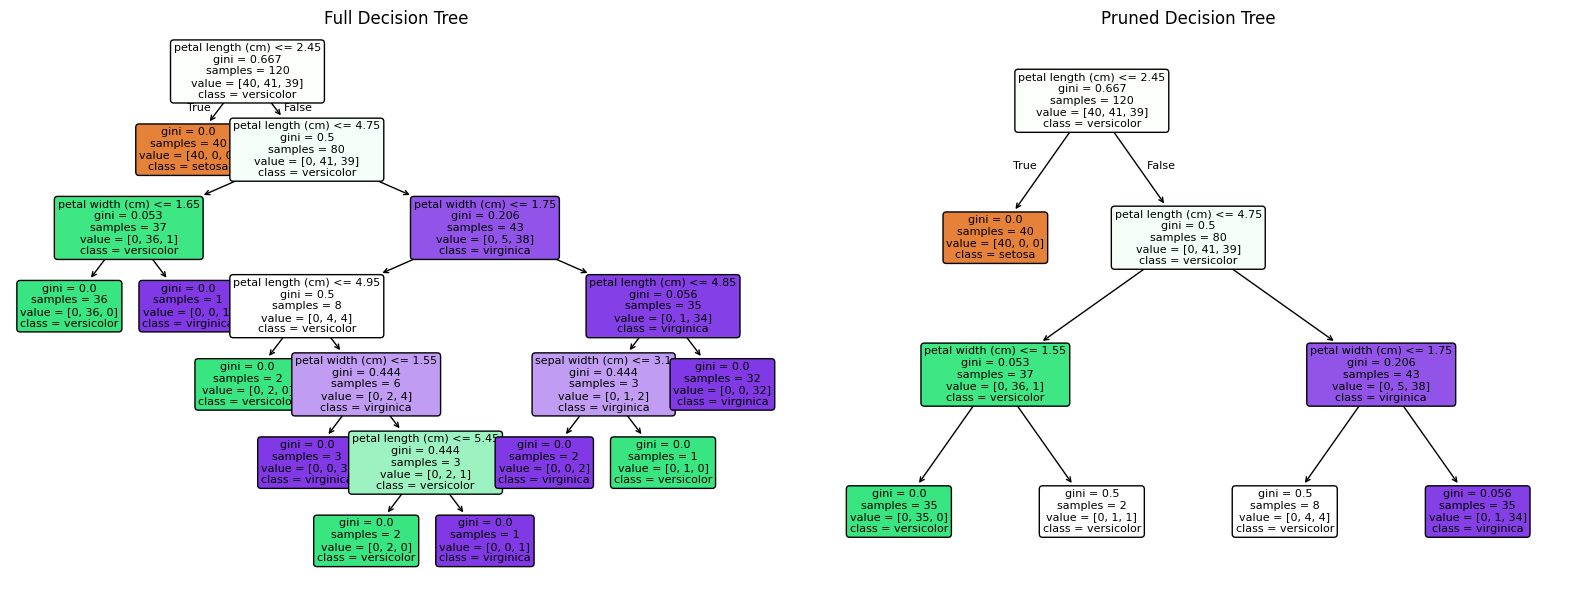

In [ ]:
# VISUALIZATION (SIDE BY SIDE)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full tree
plot_tree(
    full_tree,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True,
    rounded=True,
    ax=axes[0],
    fontsize=8
)
axes[0].set_title("Full Decision Tree")

# Pruned tree
plot_tree(
    pruned_tree,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True,
    rounded=True,
    ax=axes[1],
    fontsize=8
)
axes[1].set_title("Pruned Decision Tree")

plt.tight_layout()
plt.show()